In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import io

In [2]:
# Mapping of model filenames to standardized model names
MODEL_MAP = {
    'Llama-3.2-3B.Q4_K_M.gguf': 'Llama-3.2-3B',
    'Meta-Llama-3.1-8B-Instruct-Q4_K_M.gguf': 'Llama-3.1-8B',
    'Mistral-Small-24B-Instruct-2501-Q2_K.gguf': 'Mistral-24B',
    'llama3.2:3b': 'Llama-3.2-3B',
    'llama3.1:8b-instruct-q4_K_M': 'Llama-3.1-8B',
    'hf.co/bartowski/Mistral-Small-24B-Instruct-2501-GGUF:Q2_K': 'Mistral-24B'
}

# Processing LLama Bench Results
def process_llama_bench(csv_path):
    df = pd.read_csv(csv_path).replace('"', '', regex=True)
    # Extract filename from path
    df['clean_model'] = df['model_filename'].apply(lambda x: x.split('/')[-1])
    df['model_name'] = df['clean_model'].map(MODEL_MAP)
    
    # TTFT is from rows where n_gen == 0 (Prompt processing)
    # avg_ns is nanoseconds -> convert to seconds
    ttft_df = df[df['n_gen'] == 0][['model_name', 'scenario', 'avg_ns']].copy()
    ttft_df['ttft'] = ttft_df['avg_ns'] / 1e9
    
    # TPS is from rows where n_prompt == 0 (Generation)
    tps_df = df[df['n_prompt'] == 0][['model_name', 'scenario', 'avg_ts']].copy()
    tps_df = tps_df.rename(columns={'avg_ts': 'tps'})
    
    merged = pd.merge(ttft_df, tps_df, on=['model_name', 'scenario'])
    merged['benchmark'] = 'llama-bench'
    return merged[['model_name', 'scenario', 'tps', 'ttft', 'benchmark']]

# Processing Llama CLI Results
def process_llama_cli(csv_path):
    df = pd.read_csv(csv_path)
    df['model_name'] = df['model'].map(MODEL_MAP)
    df['benchmark'] = 'llama-cli'
    return df[['model_name', 'scenario', 'tps', 'ttft_s', 'benchmark']].rename(columns={'ttft_s': 'ttft'})

# Processing Ollama Results
def process_ollama(json_path):
    with open(json_path, 'r') as f:
        data = json.load(f)
    df = pd.DataFrame(data)
    df['model_name'] = df['model'].map(MODEL_MAP)
    df['benchmark'] = 'Ollama'
    return df[['model_name', 'scenario', 'tps', 'ttft', 'benchmark']]

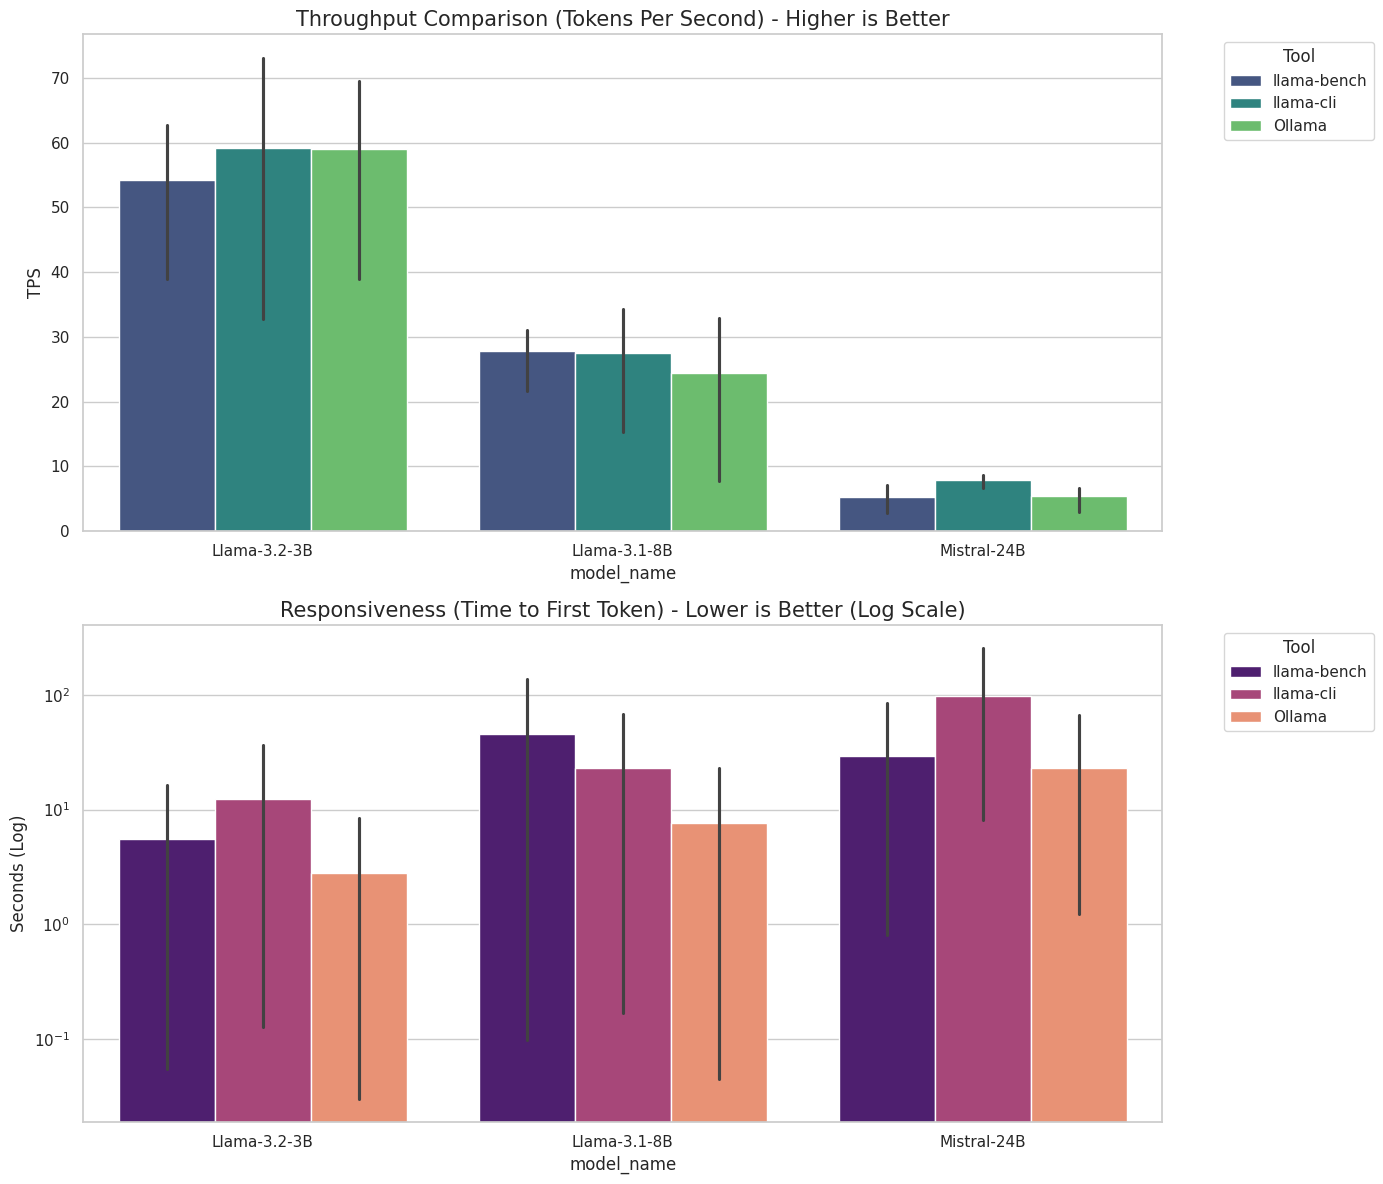

In [3]:
# Data Processinng and Plotting
df_bench = process_llama_bench('../results/llama_bench_results.csv')
df_cli = process_llama_cli('../results/llama_cli_results.csv')
df_ollama = process_ollama('../results/ollama_results.json')

# Combine all results
df_final = pd.concat([df_bench, df_cli, df_ollama], ignore_index=True)

# 3. PLOTTING
sns.set_theme(style="whitegrid")

# Create a figure with two subplots (TPS and TTFT)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

# --- Plot 1: Tokens Per Second (Higher is Better) ---
sns.barplot(data=df_final, x='model_name', y='tps', hue='benchmark', ax=ax1, palette='viridis')
ax1.set_title('Throughput Comparison (Tokens Per Second) - Higher is Better', fontsize=15)
ax1.set_ylabel('TPS')
ax1.legend(title='Tool', bbox_to_anchor=(1.05, 1), loc='upper left')

# --- Plot 2: TTFT (Lower is Better) ---
# We use Log scale because Long Context values (279s) dwarf Simple QKV values (0.04s)
sns.barplot(data=df_final, x='model_name', y='ttft', hue='benchmark', ax=ax2, palette='magma')
ax2.set_yscale('log')
ax2.set_title('Responsiveness (Time to First Token) - Lower is Better (Log Scale)', fontsize=15)
ax2.set_ylabel('Seconds (Log)')
ax2.legend(title='Tool', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('llm_benchmark_comparison.png', dpi=300)
plt.show()